# Pipeline Deep Dive: Agents, Router & Memory

> ⚠️ **Most cells require an LLM API key.**


## 1. Setup

In [1]:
import os, warnings, sys, pathlib
warnings.filterwarnings('ignore')
os.environ.setdefault('FF_LOG_LEVEL', 'warning')
sys.path.insert(0, str(pathlib.Path('.').resolve()))

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import asyncio
import nest_asyncio; nest_asyncio.apply()

from feature_forge.config import Settings, LLMConfig, RouterConfig
from _utils import get_llm_client, llm_available, make_sample_data

X_train, X_test, y_train, y_test = make_sample_data(n_samples=250, n_features=8, n_informative=5)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

llm = get_llm_client()
if llm is None: print('No LLM key. LLM cells will be skipped.')


Train: (175, 8), Test: (75, 8)


## 2. Built-in Agents

In [2]:
from feature_forge.agents import AgentRegistry
agents = AgentRegistry.get_builtin_agents()
print(f'{len(agents)} built-in agents:')
for name, cls in agents.items(): print(f'  {name}: {cls.__name__}')


6 built-in agents:
  unary: UnaryFeatureAgent
  cross_compositional: CrossCompositionalAgent
  aggregation: AggregationConstructAgent
  temporal: TemporalFeatureAgent
  local_transform: LocalTransformAgent
  local_pattern: LocalPatternAgent


In [3]:
from feature_forge.agents.router import RouterAgent
for name, caps in RouterAgent.AGENT_CAPABILITIES.items():
    print(f'{name}: {caps["description"]}')


unary: Generates features from single columns
cross_compositional: Generates cross features between 2+ columns
aggregation: Generates aggregation-based features
temporal: Generates time-based features
local_transform: Generates local transformation features
local_pattern: Generates features based on distributional patterns


In [4]:
from feature_forge.agents import BaseFeatureAgent
class PolynomialAgent(BaseFeatureAgent):
    agent_name = 'polynomial'
    prompt_filename = ''
    @property
    def system_prompt(self): return 'Generate polynomial features.'
print('PolynomialAgent defined (needs config + llm_client to instantiate)')


PolynomialAgent defined (needs config + llm_client to instantiate)


## 3. Router Strategies

In [5]:
from feature_forge.agents.router import RouterAgent
router_dd = RouterAgent(Settings(router=RouterConfig(strategy='data_driven')))
selected = await router_dd.select_agents(0, df=X_train, task_description='binary classification')
print(f'data_driven: {selected}')


data_driven: ['unary', 'cross_compositional', 'aggregation', 'temporal', 'local_transform', 'local_pattern']


In [6]:
router_perf = RouterAgent(Settings(router=RouterConfig(strategy='performance_driven')))
router_perf.update_performance('unary', 0.05)
router_perf.update_performance('cross_compositional', 0.03)
router_perf.update_performance('aggregation', -0.01)
selected = await router_perf.select_agents(1, df=X_train, task_description='classification')
print(f'performance_driven: {selected}')


performance_driven: ['unary', 'cross_compositional']


In [7]:
router_hybrid = RouterAgent(Settings(router=RouterConfig(strategy='hybrid')))
router_hybrid.update_performance('unary', 0.04)
selected = await router_hybrid.select_agents(1, df=X_train, task_description='classification')
print(f'hybrid: {selected}')


hybrid: ['unary', 'cross_compositional']


In [8]:
if llm is None:
    print('Skipping LLM router — no API key.')
else:
    try:
        router_llm = RouterAgent(Settings(router=RouterConfig(strategy='llm')), llm_client=llm)
        selected = await router_llm.select_agents(0, df=X_train, task_description='classification')
        print(f'llm: {selected}')
    except Exception as e:
        print(f'LLM router error: {type(e).__name__}: {e}')


llm: ['unary', 'cross_compositional', 'aggregation', 'temporal', 'local_transform', 'local_pattern']


## 4. Iterative Pipeline

In [9]:
from feature_forge.api import FeatureForge
fe = None
if llm is None:
    print('Skipping pipeline demo — no API key.')
else:
    try:
        fe = FeatureForge(config=Settings(n_rounds=3, metric='auc'), llm_client=llm, mode='full')
        fe.fit(X_train, y_train)
        print(f'Selected features: {fe.selected_features}')
        if fe.pipeline_result:
            for ra in fe.pipeline_result.get('round_artifacts', []):
                print(f'  Round {ra.get("round", "?")}: agents={ra.get("agents", [])}')
    except Exception as e:
        print(f'Pipeline error: {type(e).__name__}: {e}')


{"error": "Python syntax error: invalid syntax (<unknown>, line 268)", "attempt": 0, "event": "code_gen_ast_invalid", "level": "warning", "timestamp": "2026-05-13T12:46:27.811997Z", "span": null}


{"error": "Python syntax error: '(' was never closed (<unknown>, line 267)", "event": "code_gen_ast_retry_failed", "level": "error", "timestamp": "2026-05-13T12:46:57.603884Z", "span": null}


{"attempt": 0, "error": "Invalid syntax: '(' was never closed (<unknown>, line 267)", "event": "sandbox_execution_retry", "level": "warning", "timestamp": "2026-05-13T12:46:57.604834Z", "span": null}


{"error": "Python syntax error: '(' was never closed (<unknown>, line 248)", "attempt": 0, "event": "code_gen_ast_invalid", "level": "warning", "timestamp": "2026-05-13T12:47:25.379216Z", "span": null}


{"attempt": 0, "error": "Feature generation execution failed: 'numpy.ndarray' object has no attribute 'fillna'", "event": "sandbox_execution_retry", "level": "warning", "timestamp": "2026-05-13T12:49:12.941525Z", "span": null}


{"attempt": 1, "error": "Feature generation execution failed: fp and xp are not of the same length.", "event": "sandbox_execution_retry", "level": "warning", "timestamp": "2026-05-13T12:49:32.989385Z", "span": null}


Selected features: ['f6_f7_median', 'f0_neg_abs_cos', 'f0_f7_squared_diff', 'f2_f3_min', 'f2_f3_abs_diff', 'f6_f7_median_neg_abs_tanh']
  Round 1: agents=['unary', 'cross_compositional', 'aggregation', 'temporal', 'local_transform', 'local_pattern']
  Round 2: agents=['unary', 'cross_compositional', 'aggregation', 'local_transform']
  Round 3: agents=['unary', 'cross_compositional', 'aggregation', 'local_transform']


## 5. Memory System

In [10]:
from feature_forge.memory.base import AgentMemory
mem = AgentMemory('unary', memory_path='/tmp/ff_demo_memory.json')
mem.record_procedure(base_columns=['f1'], transform='log1p(f1)', feature_name='log_f1', ty='unary', description='Log f1', round_idx=0)
mem.record_feedback(feature_name='log_f1', metric='auc', value=0.03, effective=True, round_idx=0, base=['f1'], ty='unary')
print(f'Procedural: {len(mem.procedural)}, Feedback: {len(mem.feedback)}')
print(f'Stats: {mem.compute_stats()}')


Procedural: 1, Feedback: 1
Stats: {'effective_transforms': {'log1p(f1)': 1}, 'effective_fields': {'f1': 1}, 'effective_types': {'unary': 1}}


## 6. Ablation / Pipeline Modes

| Mode | Description |
|------|-------------|
| `full` | Router + memory |
| `no_memory` | No memory across rounds |
| `no_router` | All agents every round |
| `unary` etc. | Single agent only |


{"error": "Python syntax error: '(' was never closed (<unknown>, line 280)", "attempt": 0, "event": "code_gen_ast_invalid", "level": "warning", "timestamp": "2026-05-13T12:50:54.590990Z", "span": null}


{"attempt": 0, "error": "generate_features must return a DataFrame, got NoneType", "event": "sandbox_execution_retry", "level": "warning", "timestamp": "2026-05-13T12:52:14.015729Z", "span": null}


{"error": "Python syntax error: unterminated string literal (detected at line 233) (<unknown>, line 233)", "attempt": 0, "event": "code_gen_ast_invalid", "level": "warning", "timestamp": "2026-05-13T12:52:40.644593Z", "span": null}


{"error": "Python syntax error: unterminated string literal (detected at line 229) (<unknown>, line 229)", "event": "code_gen_ast_retry_failed", "level": "error", "timestamp": "2026-05-13T12:53:06.614137Z", "span": null}


{"attempt": 1, "error": "Invalid syntax: unterminated string literal (detected at line 229) (<unknown>, line 229)", "event": "sandbox_execution_retry", "level": "warning", "timestamp": "2026-05-13T12:53:06.615024Z", "span": null}


{"attempt": 0, "error": "Feature generation execution failed: Cannot set a DataFrame with multiple columns to the single column feature_rank_order", "event": "sandbox_execution_retry", "level": "warning", "timestamp": "2026-05-13T12:54:17.209885Z", "span": null}


{"error": "Python syntax error: unterminated string literal (detected at line 241) (<unknown>, line 241)", "attempt": 0, "event": "code_gen_ast_invalid", "level": "warning", "timestamp": "2026-05-13T12:55:25.518573Z", "span": null}


  full: -1 features
  no_memory: 4 features
  unary: 0 features


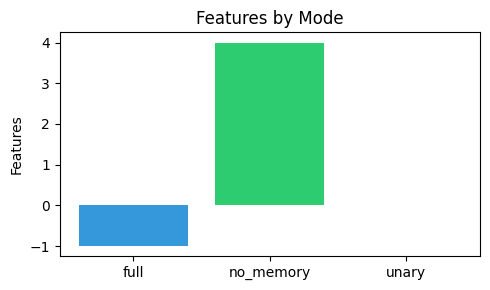

In [11]:
if llm is None:
    print('Skipping ablation — no API key.')
else:
    ablation_results = {}
    for mode in ['full', 'no_memory', 'unary']:
        try:
            fe_abl = FeatureForge(config=Settings(n_rounds=2, metric='auc'), llm_client=llm, mode=mode)
            fe_abl.fit(X_train, y_train)
            ablation_results[mode] = len(fe_abl.selected_features)
        except Exception:
            ablation_results[mode] = -1
    for mode, n in ablation_results.items(): print(f'  {mode}: {n} features')
    if ablation_results:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.bar(ablation_results.keys(), ablation_results.values(), color=['#3498db', '#2ecc71', '#e67e22'])
        ax.set_ylabel('Features'); ax.set_title('Features by Mode')
        plt.tight_layout(); plt.show()


## Summary

Next: **[03_benchmarks_and_artifacts.ipynb](./03_benchmarks_and_artifacts.ipynb)**
